In [ ]:
%matplotlib inline
import re
import sys
import os
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer
from underthesea import word_tokenize

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

import psycopg2
def get_connection():
    return psycopg2.connect(
        host='localhost',
        port=os.getenv('POSTGRES_PORT'),
        dbname=os.getenv('POSTGRES_DB'),
        user=os.getenv('POSTGRES_USER'),
        password=os.getenv('POSTGRES_PASSWORD'),
    )

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

In [63]:
conn = get_connection()
df_raw = pd.read_sql('SELECT * FROM articles ORDER BY id', conn)
conn.close()

def fix_text(x):
    if not isinstance(x, str):
        return x
    try:
        return x.encode('latin1').decode('utf-8')
    except Exception:
        return x

for col in ['title', 'content', 'url']:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].apply(fix_text)

MOJIBAKE_PATTERNS = [
    ('latin1_as_utf8', r'Ã©|Ã |Ã¢|Æ°|Ã´|Ã³|Ã¹|Ã'),
    ('broken_sequences', r'â€™|â€œ|â€|â€˜|â€¦'),
]

for col in ['title', 'content']:
    for name, pattern in MOJIBAKE_PATTERNS:
        df_raw[f'{col}_{name}'] = df_raw[col].fillna('').str.contains(pattern, regex=True)

df_raw['has_mojibake'] = False
for col in ['title', 'content']:
    for name, _ in MOJIBAKE_PATTERNS:
        df_raw['has_mojibake'] |= df_raw[f'{col}_{name}']

df_raw['published_at'] = pd.to_datetime(df_raw['published_at'], utc=True, errors='coerce')
df_raw['content_len'] = df_raw['content'].fillna('').str.len()
df_raw['content'] = df_raw['content'].fillna('')
df_raw['title'] = df_raw['title'].fillna('')
df_raw['url'] = df_raw['url'].fillna('')

cutoff = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=7)
df_week = df_raw[df_raw['published_at'] >= cutoff].copy()
df_clean = (
    df_week
    .drop_duplicates(subset=['url'])
    .drop_duplicates(subset=['title'])
    .pipe(lambda d: d[~d['has_mojibake']])
    .pipe(lambda d: d[d['content_len'] >= 200])
    .reset_index(drop=True)
)

print(f'Raw DB          : {len(df_raw):,}')
print(f'Past 7 days     : {len(df_week):,}')
print(f'After all filter: {len(df_clean):,}')
df_clean.head(3)

Raw DB          : 491
Past 7 days     : 201
After all filter: 158


,id,source,title,url,image,published_at,crawled_at,content,title_latin1_as_utf8,title_broken_sequences,content_latin1_as_utf8,content_broken_sequences,has_mojibake,content_len
0,1,vnexpress,Trình duyệt Chrome ở Việt Nam được tích hợp ch...,https://vnexpress.net/trinh-duyet-chrome-o-vie...,https://i1-vnexpress.vnecdn.net/2026/04/21/gem...,2026-04-21 08:00:00+00:00,2026-04-21 10:49:03.371429+00:00,"Trong thông báo hôm 21/4, Google cho biết đã t...",False,False,False,False,False,2640
1,2,vnexpress,Cảnh 'Trái Đất lặn' quay bằng iPhone 17 Pro Max,https://vnexpress.net/canh-trai-dat-lan-quay-b...,https://i1-vnexpress.vnecdn.net/2026/04/20/rnU...,2026-04-21 02:00:00+00:00,2026-04-21 10:49:03.371429+00:00,Video quay cảnh Trái Đất lặn của Reid Wiseman....,False,False,False,False,False,1985
2,3,vnexpress,"Tim Cook rời vị trí CEO Apple, chuyển giao cho...",https://vnexpress.net/tim-cook-roi-vi-tri-ceo-...,https://i1-vnexpress.vnecdn.net/2026/04/21/app...,2026-04-20 22:35:16+00:00,2026-04-21 10:49:03.371429+00:00,"Ngày 20/4, hãng cho biết quyết định đã được Hộ...",False,False,False,False,False,3901


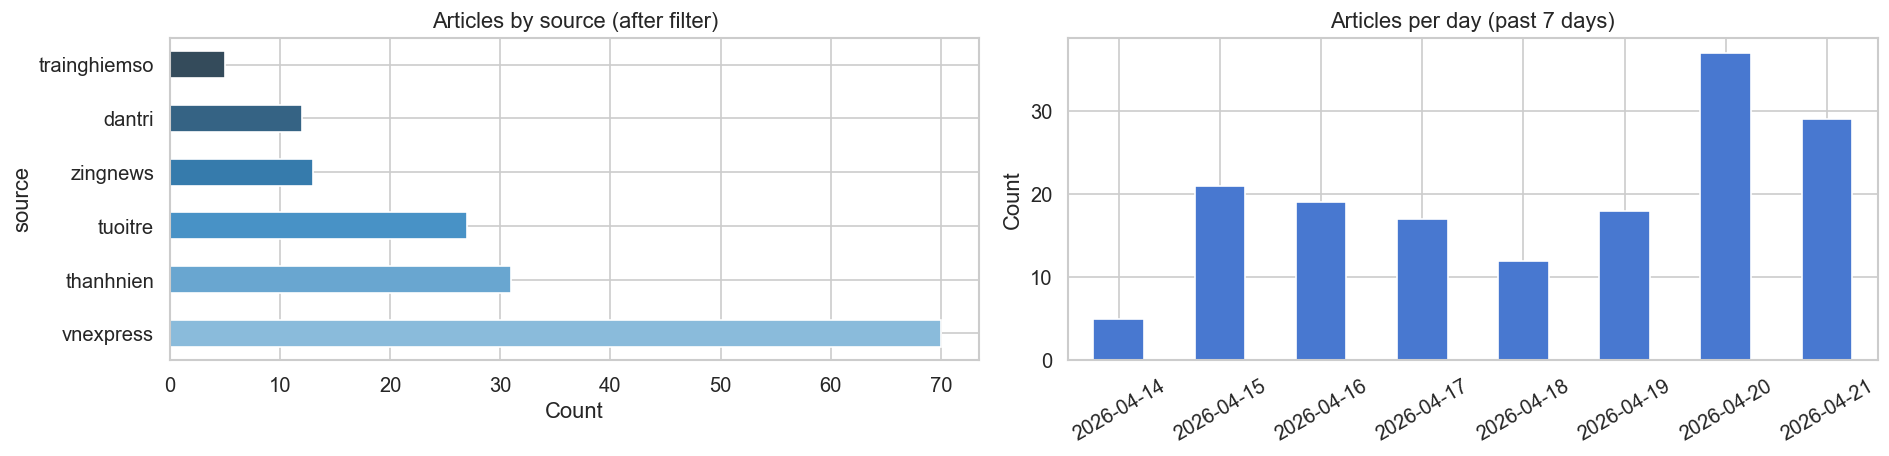

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

source_counts = df_clean['source'].value_counts()
source_counts.plot(kind='barh', ax=axes[0], color=sns.color_palette('Blues_d', len(source_counts)))
axes[0].set_title('Articles by source (after filter)')
axes[0].set_xlabel('Count')

daily = df_clean.groupby(df_clean['published_at'].dt.date).size()
daily.plot(kind='bar', ax=axes[1], color=sns.color_palette('muted')[0])
axes[1].set_title('Articles per day (past 7 days)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [65]:
IMPORTANT_ENGLISH_KEYWORDS = {
    'ai', 'ml', 'llm', 'gpt', 'openai', 'chatgpt', 'github', 'python', 'java',
    'javascript', 'typescript', 'sql', 'api', 'web', 'app', 'ios', 'android',
    'cloud', 'aws', 'azure', 'google', 'meta', 'nvidia', 'tesla', 'apple',
    'samsung', 'iphone', 'bitcoin', 'ethereum', 'blockchain', 'nft', 'metaverse',
    'vr', 'ar', 'iot', 'ota', 'crm', 'erp', 'saas', 'paas', 'iaas', 'edge',
    'quantum', 'chip', '5g', '6g', 'cpu', 'gpu', 'ram', 'ssd', 'usb',
    'wifi', 'bluetooth', 'hdmi', 'usb-c', 'oled', 'amoled',
    'battery', 'megapixel', 'fps', 'tps', 'latency', 'bandwidth',
    'vpn', 'proxy', 'firewall', 'encryption', 'hash', 'zero-day',
    'exploit', 'malware', 'ransomware', 'trojan', 'worm', 'bot', 'ddos',
    'deepseek', 'gemini', 'claude', 'copilot', 'sora', 'mistral', 'llama',
}

STOPWORDS = {
    'một_số','tuy_nhiên','đồng_thời','không_chỉ','thay_vì',
    'trong_khi','bên_cạnh','ngoài_ra','theo_đó','do_đó',
    'vì_vậy','mặc_dù','bởi_vì','chẳng_hạn','hay_là',
    'hơn','sao','tàu','kỳ','tận','ưu','tiên','nhân','ích',
    'gói','bộ','kho','nút','cúp','trẻ','già','gia','chủ',
    'thừa','khuyên','bắt','ép','mách','báo','kể','nói',
    'có_thể','sử_dụng','cho_phép','giúp_đỡ','thực_hiện',
    'xây_dựng','hoạt_động','tiếp_tục','bao_gồm','liên_quan',
    'tham_gia','chia_sẻ','thành_công','hiệu_quả','quan_trọng',
    'trong','của','với','tại','từ','theo','qua','bằng',
    'hay','còn','mà','nếu','khi','vì','để','là','và',
    'ra','vào','đến','lại','đã','sẽ','đang','được','bị',
    'một','những','nhiều','này','đây','các','cùng','đó',
    'như','sau','trên','cho','cần','có','không','làm',
    'người',
    'phát_triển','khả_năng',
    'thông_tin','nội_dung','vấn_đề','trường_hợp','thời_gian',
    'việc','điều','cách','loại','số','mức','lần','công_nghệ',
    'năm','tháng','ngày','tuần','giờ',
    'http','https','www','com','vn','html','utm','org','net',
    'họ','ta','tôi','bạn','chúng','mình','anh','chị',
    'tp','hcm',
    'được','đang','sẽ','đã','phải','cần',
    'dùng','làm','tạo','cho','giúp','trợ','thực','thấy',
    'hoặc','và','nhưng','nếu','vì','nên',
    'mới','cũ','lớn','nhỏ','tốt','xấu','nhanh',
    'dân_trí','vnexpress','thanh_niên','tuổi_trẻ','báo_chí',
    'trang_web','website','công_bố','thông_báo','tin_tức',
    'cũng','chưa','ông','vẫn','chỉ','trước','khác','thêm',
    'đạt', 'đưa',
}

In [66]:
def clean_text(text: str) -> str:
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text, flags=re.UNICODE)
    text = re.sub(r'\b\d+\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def remove_stopwords(tokenized_text: str) -> str:
    tokens = tokenized_text.split()
    filtered = []
    for t in tokens:
        is_english = t.isascii() and t.isalpha()
        is_important_english = t.lower() in IMPORTANT_ENGLISH_KEYWORDS
        if is_important_english:
            filtered.append(t)
        elif (
            t not in STOPWORDS
            and len(t) > 2
            and not t.isnumeric()
            and not is_english
        ):
            filtered.append(t)
    return ' '.join(filtered)


df_clean['text_raw'] = (df_clean['title'] + ' ' + df_clean['content']).str.lower()
df_clean['text_clean'] = df_clean['text_raw'].apply(clean_text)
df_clean['tokenized_raw'] = df_clean['text_clean'].apply(lambda x: word_tokenize(x, format='text'))
df_clean['tokenized'] = df_clean['tokenized_raw'].apply(remove_stopwords)

df_clean['token_count_before'] = df_clean['tokenized_raw'].str.split().str.len()
df_clean['token_count_after'] = df_clean['tokenized'].str.split().str.len()
df_clean['tokens_removed'] = df_clean['token_count_before'] - df_clean['token_count_after']
df_clean['removal_pct'] = (df_clean['tokens_removed'] / df_clean['token_count_before'] * 100).round(1)

print(f'Token count before - mean: {df_clean["token_count_before"].mean():.0f}, median: {df_clean["token_count_before"].median():.0f}')
print(f'Token count after  - mean: {df_clean["token_count_after"].mean():.0f}, median: {df_clean["token_count_after"].median():.0f}')
print(f'Avg tokens removed : {df_clean["tokens_removed"].mean():.0f}  ({df_clean["removal_pct"].mean():.1f}%)')

Token count before - mean: 473, median: 420
Token count after  - mean: 236, median: 198
Avg tokens removed : 237  (50.3%)


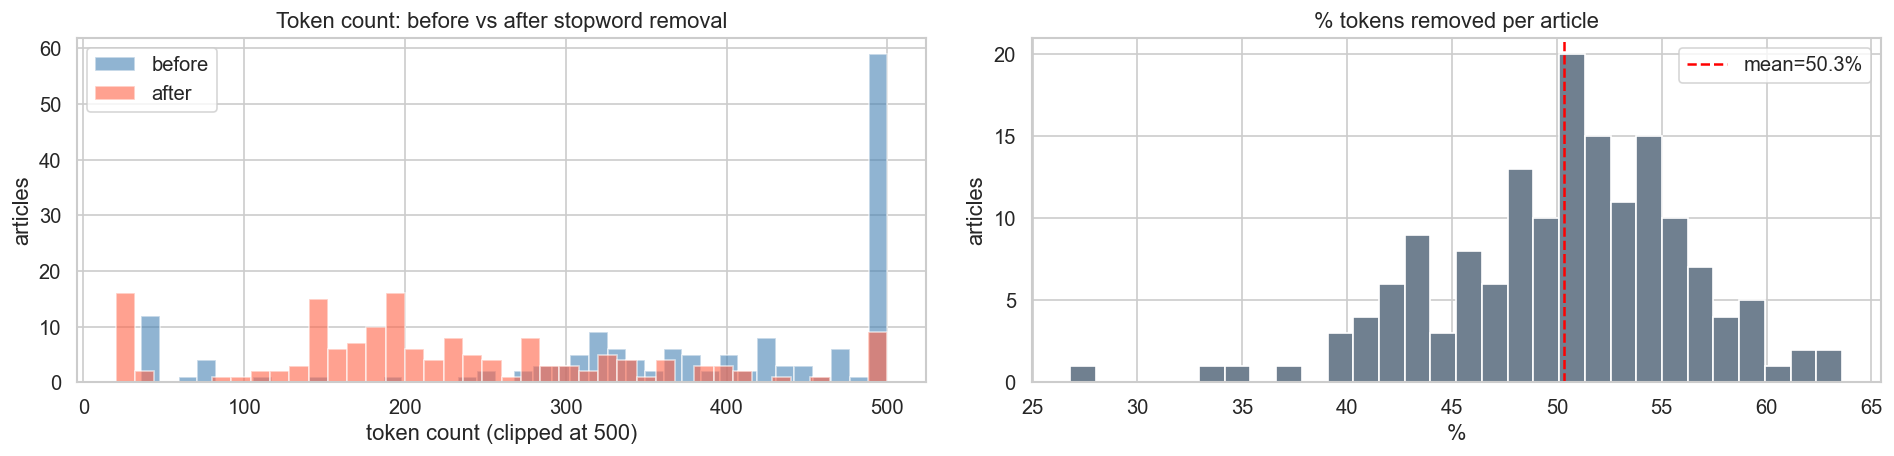

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(df_clean['token_count_before'].clip(upper=500), bins=40,
             alpha=0.6, color='steelblue', label='before')
axes[0].hist(df_clean['token_count_after'].clip(upper=500), bins=40,
             alpha=0.6, color='tomato', label='after')
axes[0].set_title('Token count: before vs after stopword removal')
axes[0].set_xlabel('token count (clipped at 500)')
axes[0].set_ylabel('articles')
axes[0].legend()

axes[1].hist(df_clean['removal_pct'], bins=30, color='slategray', edgecolor='white')
axes[1].axvline(df_clean['removal_pct'].mean(), color='red', linestyle='--',
                label=f'mean={df_clean["removal_pct"].mean():.1f}%')
axes[1].set_title('% tokens removed per article')
axes[1].set_xlabel('%')
axes[1].set_ylabel('articles')
axes[1].legend()

plt.tight_layout()
plt.show()

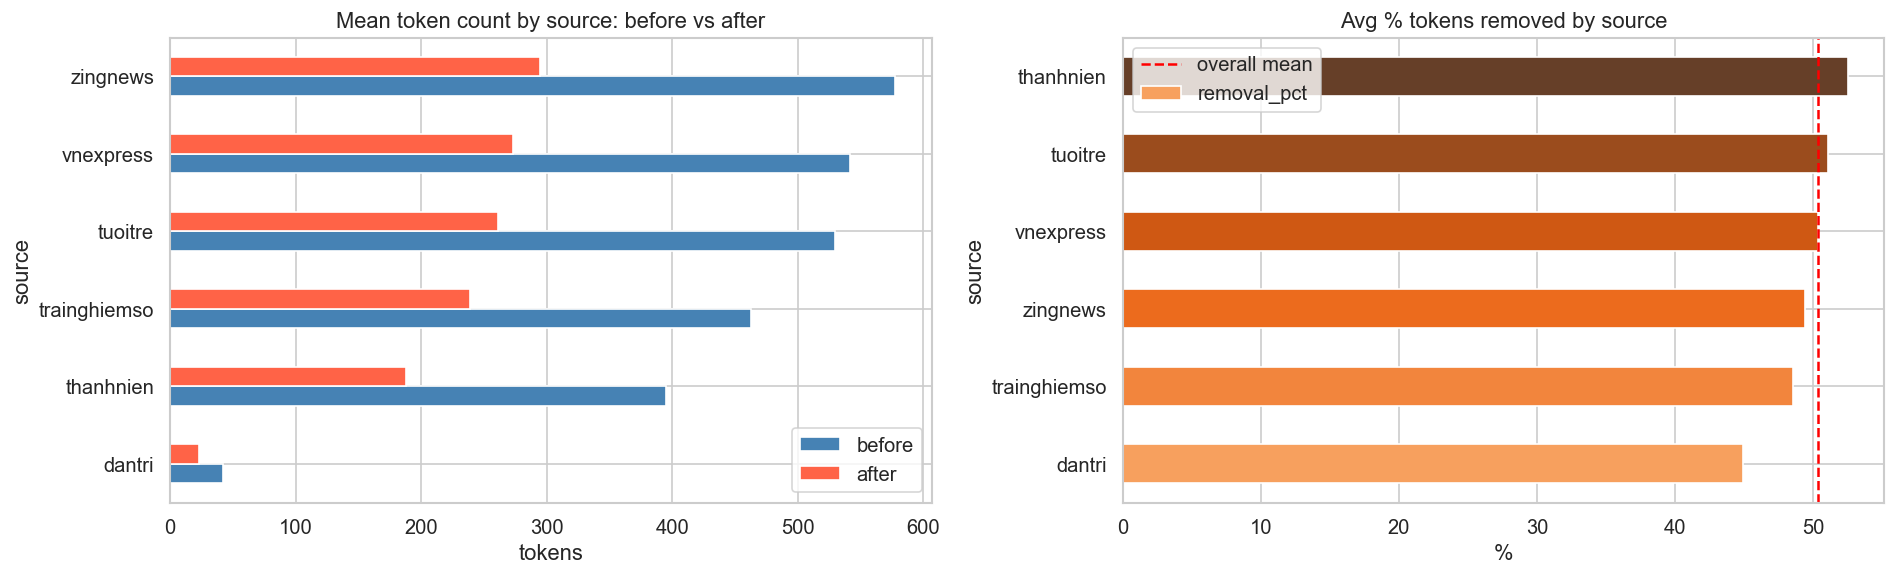

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

compare = df_clean.groupby('source')[['token_count_before', 'token_count_after']].mean().sort_values('token_count_before')
compare.plot(kind='barh', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Mean token count by source: before vs after')
axes[0].set_xlabel('tokens')
axes[0].legend(['before', 'after'])

removal_by_source = df_clean.groupby('source')['removal_pct'].mean().sort_values()
removal_by_source.plot(kind='barh', ax=axes[1], color=sns.color_palette('Oranges_d', len(removal_by_source)))
axes[1].set_title('Avg % tokens removed by source')
axes[1].set_xlabel('%')
axes[1].axvline(df_clean['removal_pct'].mean(), color='red', linestyle='--', label='overall mean')
axes[1].legend()

plt.tight_layout()
plt.show()

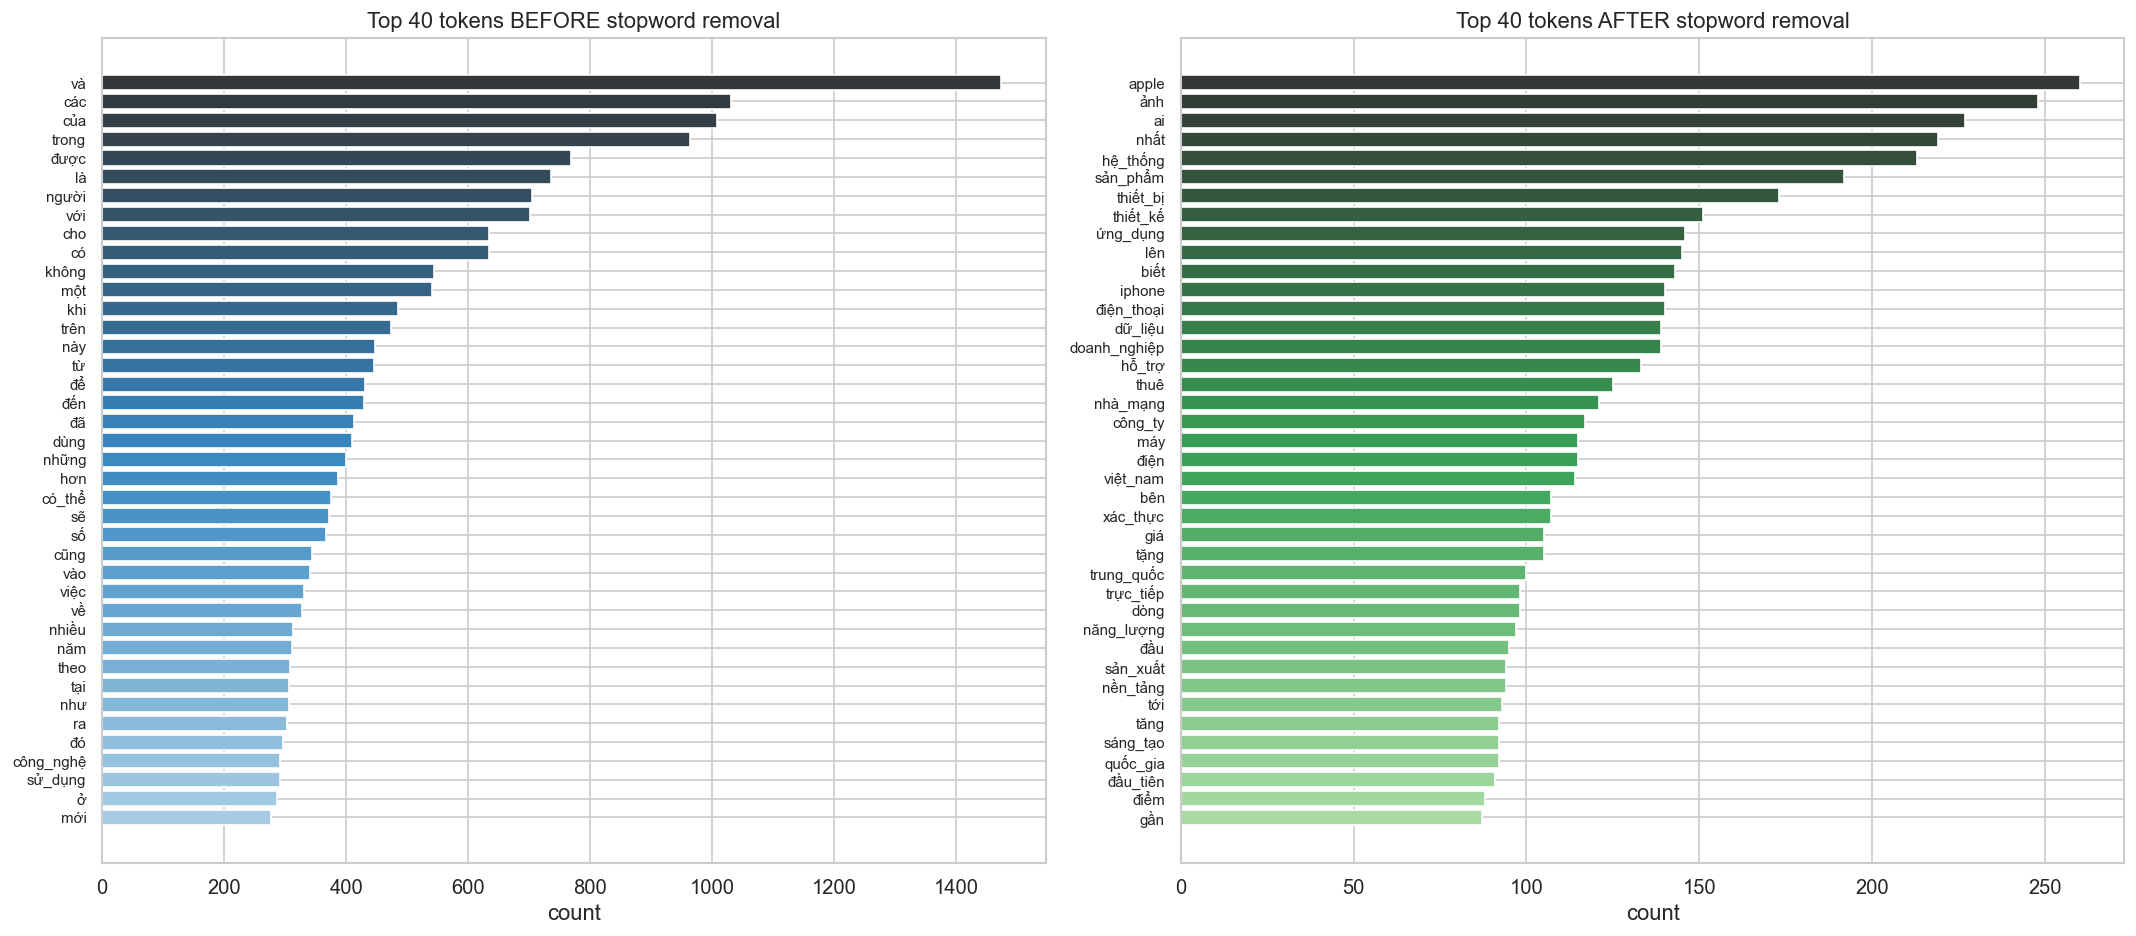

In [69]:
def top_tokens(series, n=40):
    counter = Counter()
    for text in series:
        counter.update(text.split())
    return pd.DataFrame(counter.most_common(n), columns=['token', 'count'])

top_before = top_tokens(df_clean['tokenized_raw'])
top_after  = top_tokens(df_clean['tokenized'])

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].barh(top_before['token'][::-1], top_before['count'][::-1],
             color=sns.color_palette('Blues_d', len(top_before)))
axes[0].set_title('Top 40 tokens BEFORE stopword removal')
axes[0].set_xlabel('count')
axes[0].tick_params(axis='y', labelsize=9)

axes[1].barh(top_after['token'][::-1], top_after['count'][::-1],
             color=sns.color_palette('Greens_d', len(top_after)))
axes[1].set_title('Top 40 tokens AFTER stopword removal')
axes[1].set_xlabel('count')
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

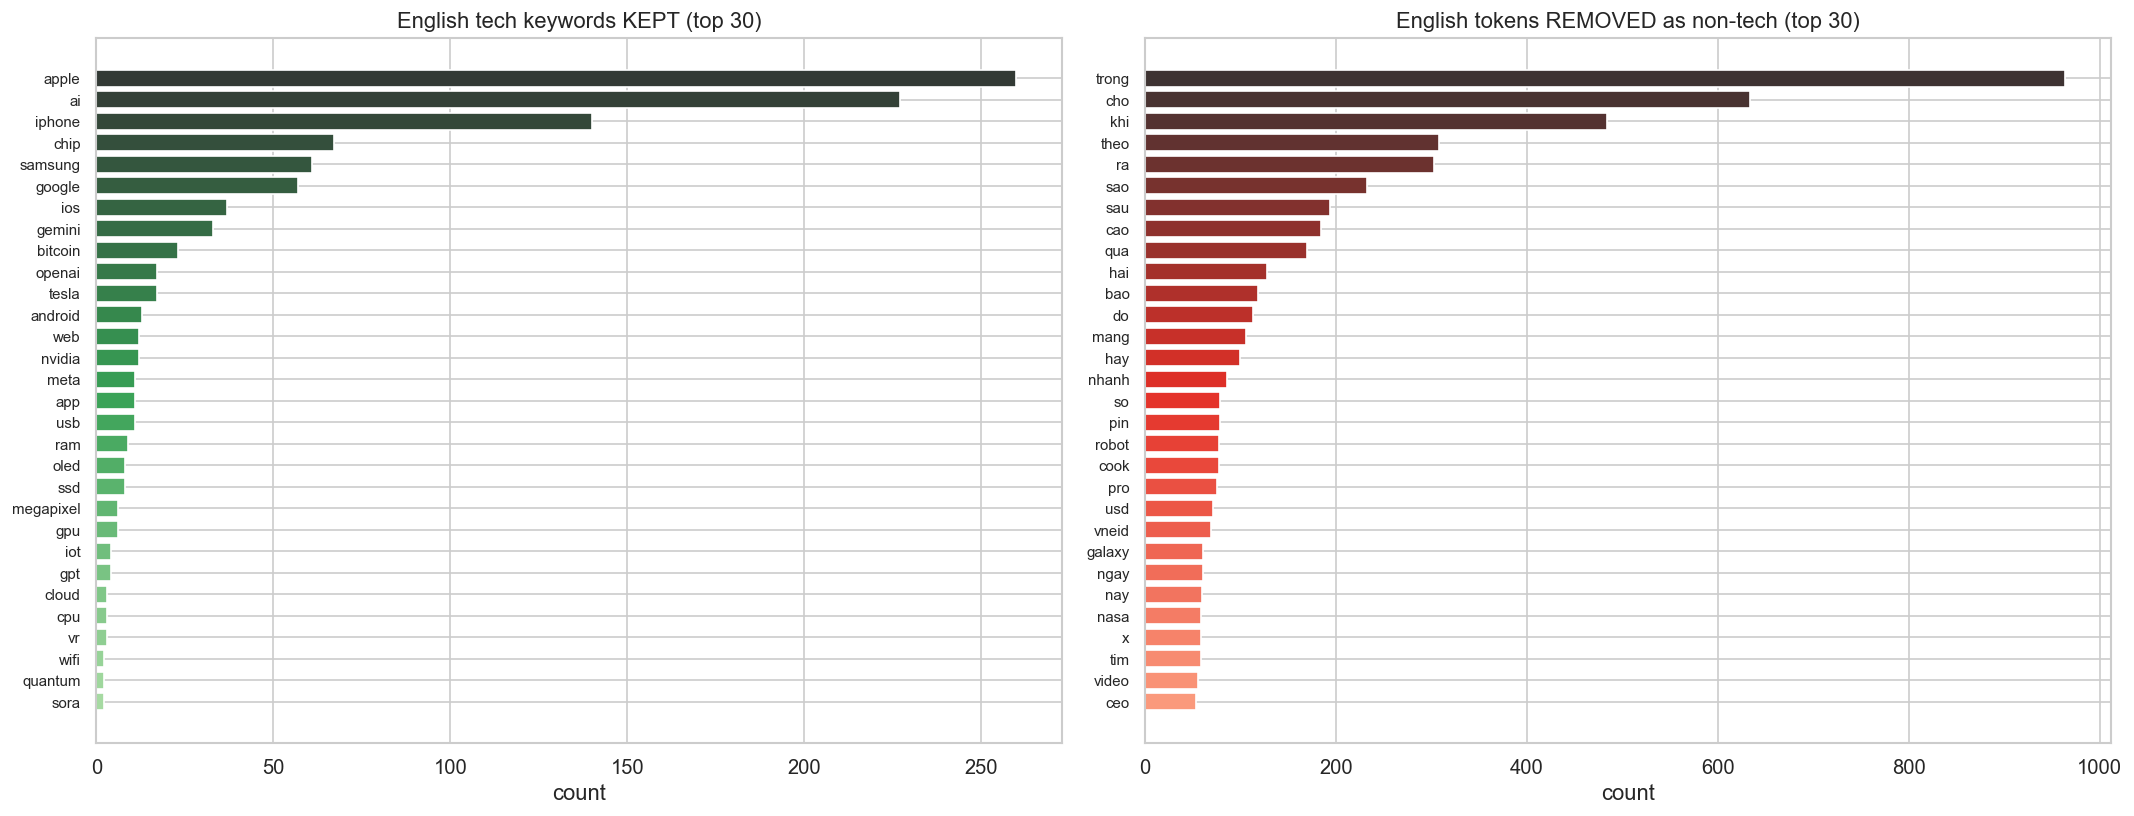

Unique English keywords kept   : 39
Total English keyword mentions : 1,082
Unique English tokens removed  : 1,327


In [70]:
eng_tokens_kept = []
for text in df_clean['tokenized']:
    for t in text.split():
        if t.isascii() and t.isalpha() and t.lower() in IMPORTANT_ENGLISH_KEYWORDS:
            eng_tokens_kept.append(t.lower())

eng_removed = []
for text in df_clean['tokenized_raw']:
    for t in text.split():
        if t.isascii() and t.isalpha() and t.lower() not in IMPORTANT_ENGLISH_KEYWORDS:
            eng_removed.append(t.lower())

kept_counts    = pd.DataFrame(Counter(eng_tokens_kept).most_common(30), columns=['keyword', 'count'])
removed_counts = pd.DataFrame(Counter(eng_removed).most_common(30), columns=['token', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(kept_counts['keyword'][::-1], kept_counts['count'][::-1],
             color=sns.color_palette('Greens_d', len(kept_counts)))
axes[0].set_title('English tech keywords KEPT (top 30)')
axes[0].set_xlabel('count')
axes[0].tick_params(axis='y', labelsize=9)

axes[1].barh(removed_counts['token'][::-1], removed_counts['count'][::-1],
             color=sns.color_palette('Reds_d', len(removed_counts)))
axes[1].set_title('English tokens REMOVED as non-tech (top 30)')
axes[1].set_xlabel('count')
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

print(f'Unique English keywords kept   : {len(set(eng_tokens_kept)):,}')
print(f'Total English keyword mentions : {len(eng_tokens_kept):,}')
print(f'Unique English tokens removed  : {len(set(eng_removed)):,}')

In [71]:
MIN_TOKEN_LEN = 20
df_final = df_clean[df_clean['token_count_after'] >= MIN_TOKEN_LEN].reset_index(drop=True)

print(f'Articles before min-token filter : {len(df_clean):,}')
print(f'Dropped (< {MIN_TOKEN_LEN} tokens)         : {len(df_clean) - len(df_final):,}')
print(f'Articles after min-token filter  : {len(df_final):,}')
print()
print(df_final['token_count_after'].describe().to_string())

Articles before min-token filter : 158
Dropped (< 20 tokens)         : 0
Articles after min-token filter  : 158

count     158.000000
mean      236.208861
std       168.480434
min        20.000000
25%       151.000000
50%       198.000000
75%       287.000000
max      1141.000000


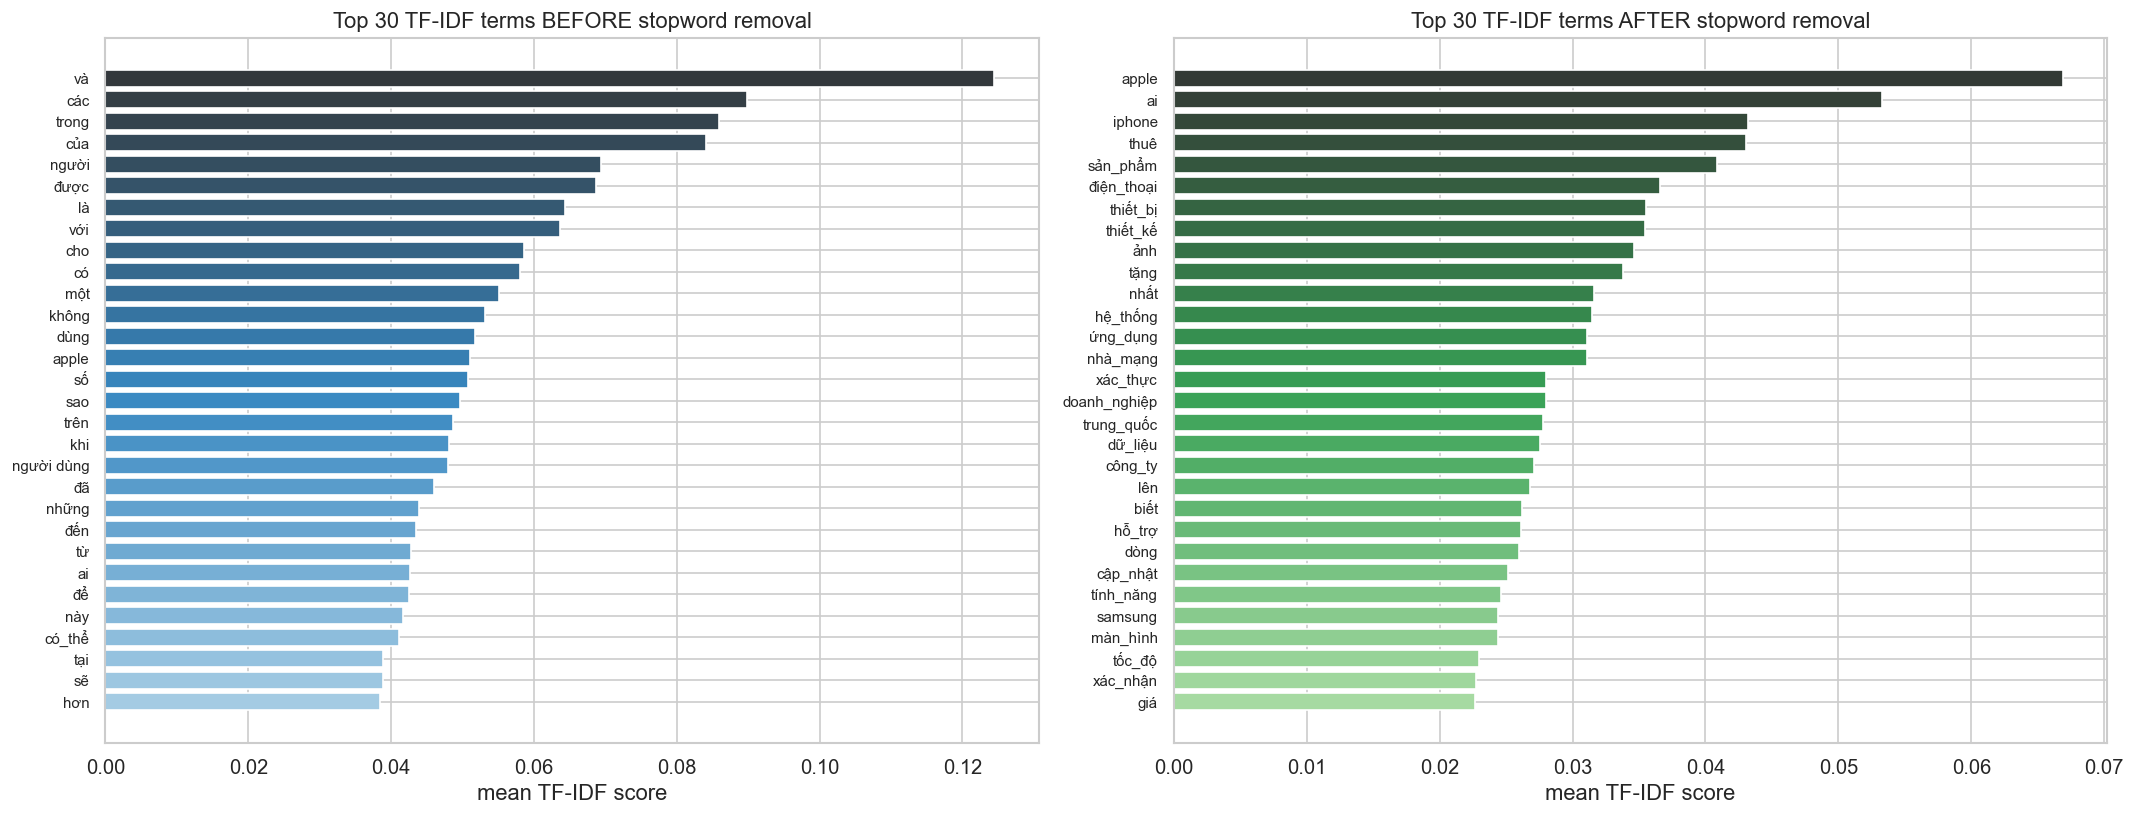

In [72]:
tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    token_pattern=r'(?u)\b\w\w+\b',
    min_df=2,
)

mat_before = tfidf.fit_transform(df_final['tokenized_raw'])
scores_before = dict(zip(tfidf.get_feature_names_out(), mat_before.mean(axis=0).A1))

mat_after = tfidf.fit_transform(df_final['tokenized'])
scores_after = dict(zip(tfidf.get_feature_names_out(), mat_after.mean(axis=0).A1))

top_before_tfidf = pd.DataFrame(sorted(scores_before.items(), key=lambda x: x[1], reverse=True)[:30],
                                 columns=['term', 'score'])
top_after_tfidf  = pd.DataFrame(sorted(scores_after.items(),  key=lambda x: x[1], reverse=True)[:30],
                                 columns=['term', 'score'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(top_before_tfidf['term'][::-1], top_before_tfidf['score'][::-1],
             color=sns.color_palette('Blues_d', 30))
axes[0].set_title('Top 30 TF-IDF terms BEFORE stopword removal')
axes[0].set_xlabel('mean TF-IDF score')
axes[0].tick_params(axis='y', labelsize=9)

axes[1].barh(top_after_tfidf['term'][::-1], top_after_tfidf['score'][::-1],
             color=sns.color_palette('Greens_d', 30))
axes[1].set_title('Top 30 TF-IDF terms AFTER stopword removal')
axes[1].set_xlabel('mean TF-IDF score')
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

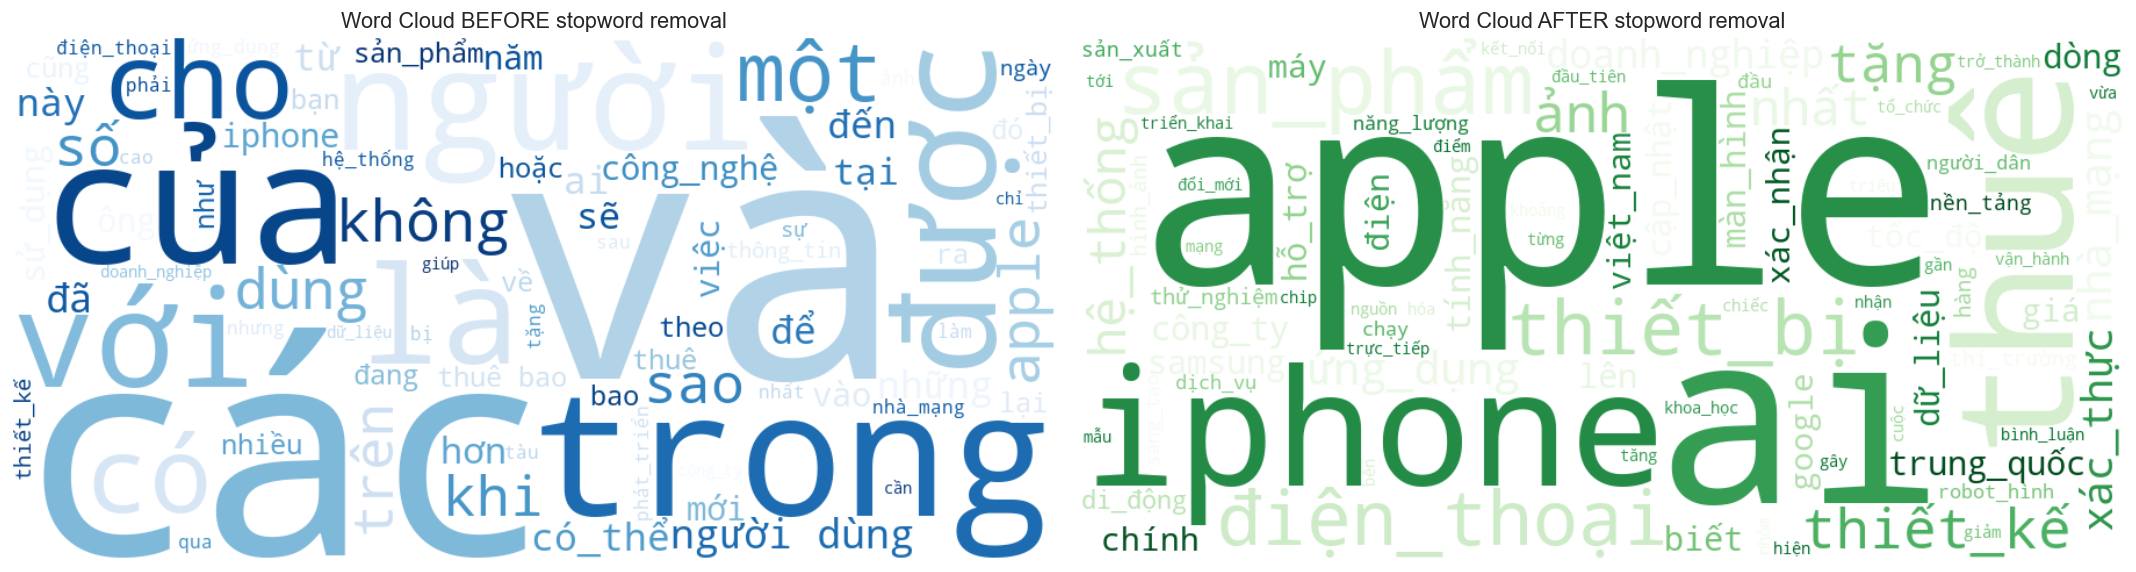

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

wc_before = WordCloud(width=900, height=450, background_color='white', colormap='Blues', max_words=80)
wc_before.generate_from_frequencies(scores_before)
axes[0].imshow(wc_before, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud BEFORE stopword removal', fontsize=13)

wc_after = WordCloud(width=900, height=450, background_color='white', colormap='Greens', max_words=80)
wc_after.generate_from_frequencies(scores_after)
axes[1].imshow(wc_after, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud AFTER stopword removal', fontsize=13)

plt.tight_layout()
plt.show()

In [74]:
MODEL_NAME = 'keepitreal/vietnamese-sbert'
sbert = SentenceTransformer(MODEL_NAME)
print(f'Model loaded: {MODEL_NAME}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 515.13it/s, Materializing param=pooler.dense.weight]                               
RobertaModel LOAD REPORT from: keepitreal/vietnamese-sbert
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: keepitreal/vietnamese-sbert


In [75]:
TECH_QUERIES = [
    'trí tuệ nhân tạo AI machine learning deep learning mô hình chatgpt openai gemini',
    'điện thoại smartphone iphone samsung chip vi xử lý màn hình camera',
    'phần mềm ứng dụng lập trình code backend frontend framework',
    'an ninh mạng bảo mật dữ liệu hacker tấn công mã hóa',
    'xe điện năng lượng pin sạc xe tự lái ô tô điện',
    'mạng xã hội facebook tiktok youtube instagram người dùng nội dung',
    'khởi nghiệp startup đầu tư gọi vốn định giá IPO',
    'máy tính laptop desktop server chip CPU GPU',
    'blockchain bitcoin ethereum tiền mã hóa crypto',
]

texts_for_embed = (df_final['title'] + '. ' + df_final['content'].str[:512]).tolist()
article_embeddings = sbert.encode(
    texts_for_embed, batch_size=64, show_progress_bar=True, normalize_embeddings=True
)
query_embeddings = sbert.encode(TECH_QUERIES, normalize_embeddings=True)

sim_matrix = cosine_similarity(article_embeddings, query_embeddings)

df_final = df_final.copy()
df_final['tech_score'] = sim_matrix.max(axis=1)
df_final['tech_topic_idx'] = sim_matrix.argmax(axis=1)
df_final['tech_topic'] = [TECH_QUERIES[i] for i in df_final['tech_topic_idx']]

print(df_final[['title', 'source', 'tech_score', 'tech_topic']].sort_values('tech_score', ascending=False).head(10).to_string())
print(f'\nScore range: {df_final["tech_score"].min():.3f} - {df_final["tech_score"].max():.3f}')
print(df_final['tech_score'].quantile([.25, .5, .75, .9, .95]).to_string())

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches: 100%|██████████| 3/3 [00:19<00:00,  6.53s/it]


                                                                                      title        source  tech_score                                                                        tech_topic
147                           Microsoft chính thức vận hành trung tâm AI mạnh nhất thế giới        dantri    0.574576  trí tuệ nhân tạo AI machine learning deep learning mô hình chatgpt openai gemini
145  ROG Flow Z13-KJP và TUF Gaming A14 2026 trang bị AMD Ryzen AI Max+ ra mắt tại Việt Nam  trainghiemso    0.567964                                       máy tính laptop desktop server chip CPU GPU
18                                               Lợi thế khi OpenClaw triển khai trên Cloud     vnexpress    0.557214  trí tuệ nhân tạo AI machine learning deep learning mô hình chatgpt openai gemini
108                              Google tích hợp AI vào Chrome, tìm kiếm không cần mở trang       tuoitre    0.550031                       phần mềm ứng dụng lập trình code backend frontend framework


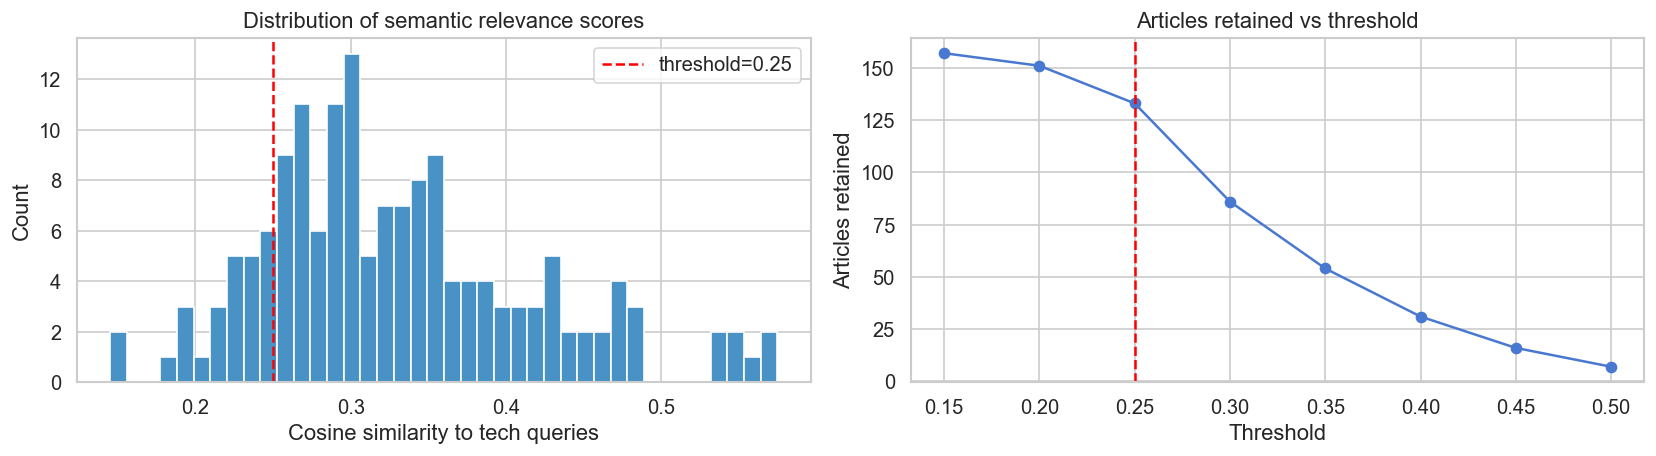

 threshold  n_articles
      0.15         157
      0.20         151
      0.25         133
      0.30          86
      0.35          54
      0.40          31
      0.45          16
      0.50           7

Selected threshold: 0.25  ->  133 / 158 articles


In [76]:
THRESHOLD = 0.25
thresholds = np.arange(0.15, 0.55, 0.05)
cov_df = pd.DataFrame(
    [(t, (df_final['tech_score'] >= t).sum()) for t in thresholds],
    columns=['threshold', 'n_articles']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_final['tech_score'], bins=40, color=sns.color_palette('Blues_d')[2], edgecolor='white')
axes[0].axvline(THRESHOLD, color='red', linestyle='--', label=f'threshold={THRESHOLD:.2f}')
axes[0].set_title('Distribution of semantic relevance scores')
axes[0].set_xlabel('Cosine similarity to tech queries')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].plot(cov_df['threshold'], cov_df['n_articles'], marker='o', color=sns.color_palette('muted')[0])
axes[1].axvline(THRESHOLD, color='red', linestyle='--')
axes[1].set_title('Articles retained vs threshold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Articles retained')
axes[1].grid(True)

plt.tight_layout()
plt.show()
print(cov_df.to_string(index=False))

tech_mask = df_final['tech_score'] >= THRESHOLD
df_tech = df_final[tech_mask].reset_index(drop=True)
tech_embeddings = article_embeddings[tech_mask.values]
print(f'\nSelected threshold: {THRESHOLD}  ->  {len(df_tech):,} / {len(df_final):,} articles')

In [77]:
tfidf_tech = TfidfVectorizer(
    max_features=300,
    ngram_range=(1, 2),
    stop_words=list(STOPWORDS),
    token_pattern=r'(?u)\b\w\w+\b',
    min_df=2,
)
tfidf_tech_matrix = tfidf_tech.fit_transform(df_tech['tokenized'])
tech_tfidf_scores = dict(zip(
    tfidf_tech.get_feature_names_out(),
    tfidf_tech_matrix.mean(axis=0).A1
))

keyword_embeds = sbert.encode(list(tech_tfidf_scores.keys()), normalize_embeddings=True, show_progress_bar=False)
query_embed_mean = normalize(query_embeddings.mean(axis=0, keepdims=True))
kw_relevance = cosine_similarity(keyword_embeds, query_embed_mean).flatten()

kw_df = pd.DataFrame({
    'keyword': list(tech_tfidf_scores.keys()),
    'tfidf': list(tech_tfidf_scores.values()),
    'semantic': kw_relevance,
})
kw_df['combined'] = kw_df['tfidf'] * kw_df['semantic']
kw_df = kw_df.sort_values('combined', ascending=False).reset_index(drop=True)

print('Top 20 tech-relevant keywords (TF-IDF x semantic):')
print(kw_df.head(20).to_string(index=False))

Top 20 tech-relevant keywords (TF-IDF x semantic):
   keyword    tfidf  semantic  combined
  hệ_thống 0.039192  0.412506  0.016167
     apple 0.074576  0.211210  0.015751
    iphone 0.049507  0.306894  0.015193
  thiết_bị 0.042684  0.332373  0.014187
  nhà_mạng 0.025790  0.515025  0.013283
  ứng_dụng 0.037412  0.339324  0.012695
  sản_phẩm 0.051207  0.213320  0.010924
  màn_hình 0.030172  0.344728  0.010401
       máy 0.024821  0.402693  0.009995
      thuê 0.044177  0.224789  0.009930
        ai 0.070661  0.133991  0.009468
  thiết_kế 0.043546  0.209440  0.009120
      chip 0.023830  0.369539  0.008806
  nền_tảng 0.026472  0.332599  0.008805
điện_thoại 0.041689  0.204456  0.008524
      dòng 0.033826  0.249000  0.008423
       ios 0.017361  0.466167  0.008093
 tính_năng 0.032470  0.244956  0.007954
năng_lượng 0.024070  0.321864  0.007747
    google 0.029276  0.262097  0.007673


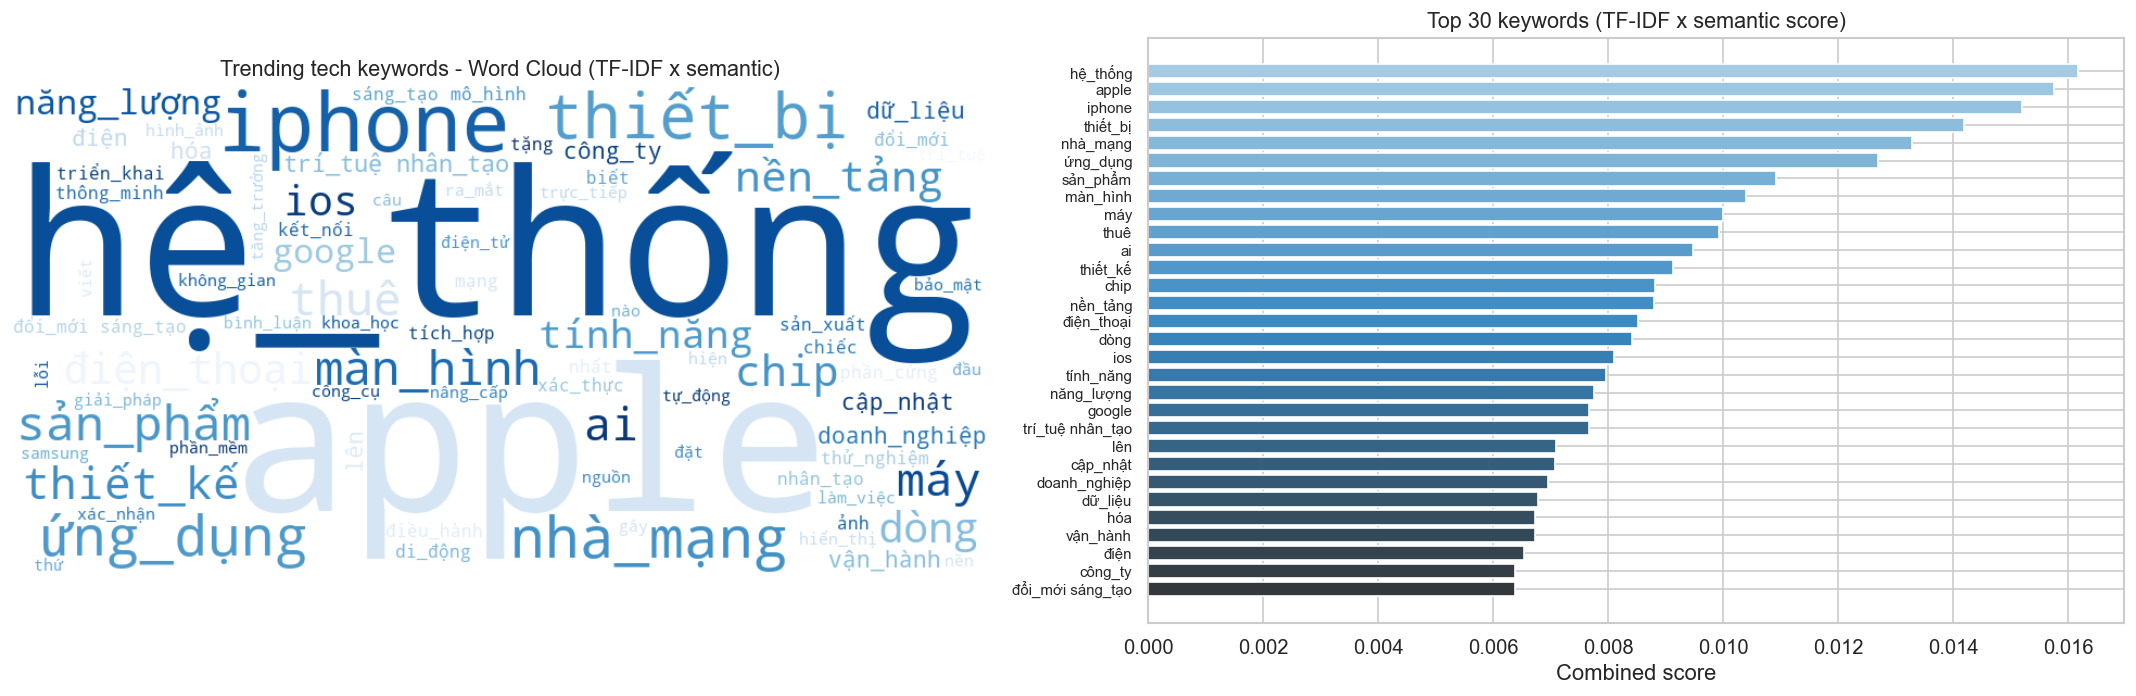

In [78]:
TOP_N = 30
top_kw = kw_df.head(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

wc = WordCloud(width=900, height=450, background_color='white', colormap='Blues', max_words=80)
wc.generate_from_frequencies(dict(zip(kw_df['keyword'], kw_df['combined'])))
axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Trending tech keywords - Word Cloud (TF-IDF x semantic)', fontsize=13)

colors = sns.color_palette('Blues_d', TOP_N)
axes[1].barh(top_kw['keyword'][::-1], top_kw['combined'][::-1], color=colors[::-1])
axes[1].set_title(f'Top {TOP_N} keywords (TF-IDF x semantic score)', fontsize=13)
axes[1].set_xlabel('Combined score')
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

In [79]:
print('Sample articles: tokenized_raw vs tokenized')
for _, row in df_tech.sample(min(3, len(df_tech)), random_state=42).iterrows():
    print(f"[{row['source']}] {row['title'][:80]}")
    print(f"  BEFORE ({row['token_count_before']} tokens): {' '.join(row['tokenized_raw'].split()[:20])} ...")
    print(f"  AFTER  ({row['token_count_after']} tokens): {' '.join(row['tokenized'].split()[:20])} ...")
    print(f"  tech_score: {row['tech_score']:.3f}")
    print()

Sample articles: tokenized_raw vs tokenized
[vnexpress] Không xác thực thuê bao ngày 15/4 có bị khóa SIM?
  BEFORE (75 tokens): không xác_thực thuê bao ngày có bị khóa sim tôi thấy nhiều người vội_vàng ra điểm giao_dịch của nhà_mạng để ...
  AFTER  (31 tokens): xác_thực thuê khóa vội_vàng điểm giao_dịch nhà_mạng thủ_tục khóa hỏi xác_thực thời_điểm thì khóa điện_thoại tất_cả thuê đều xác_thực nguyễn_trung_hà_nội ...
  tech_score: 0.328

[thanhnien] Samsung nói gì về việc Galaxy S và Galaxy A ngày càng giống nhau?
  BEFORE (373 tokens): samsung nói gì về việc galaxy s và galaxy_a ngày_càng giống nhau nhận_xét này được vị lãnh_đạosamsungđưa ra dựa trên ...
  AFTER  (183 tokens): samsung galaxy_a ngày_càng giống nhận_xét lãnh_đạosamsungđưa dựa yếu_tố thiết_kế nổi_bật cong_góc tối_ưu tương_đương cong_độ thông_số áp_dụng bút công_ty hàn_quốc khẳng_định ...
  tech_score: 0.431

[vnexpress] Bốn tính năng Apple Intelligence có thể xuất hiện trên iPhone 18
  BEFORE (285 tokens): bốn tính_năng ap